<a href="https://colab.research.google.com/github/pravallikachejerla/Data-science/blob/main/handrecog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = ':https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F39466%2F61155%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240813%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240813T090233Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D34e964676fbd62a5a3bf91ba9ab2bf858e5cf8cba5224a465f6b2009ab9c34de9ee016d33da34e5ee2a53c165363b1588dcba73870032a70a4bf9245c4058d29d843cd354d2be4104d689d7d6e345df26c39054e7fae802c28a90c03d1fc612fb845c69eeb0f0b0c237da24430ed3ef11e51ef51040ce2d85046be84187d625efcfe6d7d064fa148c459fbdc70335bc3c042ba5ce50d03943e22a9477dd5b862794edcbecf17f37983e6f7325c852a7c8ad5ce3dace3593ed6078fc8c86d530567ed12becf5612fb3285a562f06d59e1fe0dfe996b91134bc13f70177489d05155873091c5fc2970d07633661612177cb41a492cc1ee51139c45598c6c36d60f'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 2286085038 bytes downloaded
Downloaded and uncompressed: 
Data source import complete.


In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [ ]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Streaming output truncated to the last 5000 lines.
/kaggle/input/leapgestrecog/leapGestRecog/09/10_down/frame_09_10_0174.png
/kaggle/input/leapgestrecog/leapGestRecog/09/10_down/frame_09_10_0011.png
/kaggle/input/leapgestrecog/leapGestRecog/09/10_down/frame_09_10_0101.png
/kaggle/input/leapgestrecog/leapGestRecog/09/10_down/frame_09_10_0140.png
/kaggle/input/leapgestrecog/leapGestRecog/09/10_down/frame_09_10_0069.png
/kaggle/input/leapgestrecog/leapGestRecog/09/10_down/frame_09_10_0159.png
/kaggle/input/leapgestrecog/leapGestRecog/09/10_down/frame_09_10_0121.png
/kaggle/input/leapgestrecog/leapGestRecog/09/10_down/frame_09_10_0191.png
/kaggle/input/leapgestrecog/leapGestRecog/09/10_down/frame_09_10_0003.png
/kaggle/input/leapgestrecog/leapGestRecog/09/10_down/frame_09_10_0052.png
/kaggle/input/leapgestrecog/leapGestRecog/09/10_down/frame_09_10_0056.png
/kaggle/input/leapgestrecog/leapGestRecog/09/10_down/frame_09_10_0002.png
/kaggle/input/leapgestrecog/leapGestRecog/09/10_down/frame_09

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

class ModelPerformanceAnalyzer:
    def __init__(self, results):
        """
        Initialize the ModelPerformanceAnalyzer with model results.

        :param results: A dictionary where keys are model names and values are dictionaries
                        of performance metrics (e.g., accuracy, precision, recall, etc.).
        """
        self.results = results
        self.df = pd.DataFrame(results).T  # Convert results to DataFrame for easier manipulation

    def summary_statistics(self):
        """
        Calculate and print summary statistics (mean, std, min, max) for each metric.
        """
        summary = self.df.describe()
        print("Summary Statistics:")
        print(summary)

    def compare_models(self, metric):
        """
        Compare models based on a specific metric.

        :param metric: The metric to compare (e.g., 'accuracy').
        """
        if metric not in self.df.columns:
            print(f"Metric '{metric}' not found.")
            return

        best_model = self.df[metric].idxmax()
        worst_model = self.df[metric].idxmin()

        print(f"\nModel Comparison based on '{metric}':")
        print(f"Best Model: {best_model} with {metric} = {self.df.loc[best_model, metric]:.4f}")
        print(f"Worst Model: {worst_model} with {metric} = {self.df.loc[worst_model, metric]:.4f}")

    def plot_metric_distribution(self, metric, nGraphShown=10, nGraphPerRow=2):
        """
        Plot the distribution of a specific metric across models.

        :param metric: The metric to plot (e.g., 'accuracy').
        :param nGraphShown: Number of graphs to show.
        :param nGraphPerRow: Number of graphs per row.
        """
        if metric not in self.df.columns:
            print(f"Metric '{metric}' not found.")
            return

        metric_values = self.df[metric].sort_values(ascending=False).head(nGraphShown)
        nCol = len(metric_values)
        nGraphRow = int(np.ceil(nCol / nGraphPerRow))

        plt.figure(figsize=(6 * nGraphPerRow, 4 * nGraphRow), dpi=80)

        for i, (model, value) in enumerate(metric_values.items()):
            plt.subplot(nGraphRow, nGraphPerRow, i + 1)
            plt.bar(model, value)
            plt.ylim(0, 1)  # Assuming the metric is normalized between 0 and 1
            plt.ylabel(metric.capitalize())
            plt.title(f'{model} ({metric})')

        plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=2.0)
        plt.show()

    def correlation_analysis(self):
        """
        Display the correlation matrix of all metrics.
        """
        correlation_matrix = self.df.corr()
        print("\nCorrelation Matrix:")
        print(correlation_matrix)

        # Optionally, plot the correlation matrix
        plt.figure(figsize=(8, 6))
        plt.matshow(correlation_matrix, fignum=1, cmap='coolwarm')
        plt.colorbar()
        plt.title('Correlation Matrix of Metrics', pad=15)
        plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
        plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
        plt.show()

# Example usage:
# Define model performance results (example data)
# results = {
#     "Model 1": {"accuracy": 0.85, "precision": 0.80, "recall": 0.75},
#     "Model 2": {"accuracy": 0.90, "precision": 0.88, "recall": 0.82},
#     "Model 3": {"accuracy": 0.88, "precision": 0.85, "recall": 0.80},
#     "Model 4": {"accuracy": 0.92, "precision": 0.90, "recall": 0.85},
# }

# analyzer = ModelPerformanceAnalyzer(results)
# analyzer.summary_statistics()
# analyzer.compare_models('accuracy')
# analyzer.plot_metric_distribution('accuracy', nGraphShown=4, nGraphPerRow=2)
# analyzer.correlation_analysis()


In [ ]:
from sklearn.metrics import accuracy_score

def calculate_accuracy(y_true, y_pred):
    """
    Calculate the accuracy of a model's predictions.

    :param y_true: List or array of true labels.
    :param y_pred: List or array of predicted labels.
    :return: Accuracy score as a float.
    """
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Model Accuracy: {accuracy:.4f}")
    return accuracy

# Example usage:
# Suppose you have the following true labels and predicted labels
# y_true = [0, 1, 1, 0, 1, 1, 0, 0, 1, 0]
# y_pred = [0, 1, 0, 0, 1, 1, 0, 0, 1, 1]

# Calculate accuracy
# accuracy = calculate_accuracy(y_true, y_pred)


In [ ]:

import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
# Disable XLA
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'

# Set logging level to avoid unnecessary warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# Clear TensorFlow session
from tensorflow.keras import backend as K
K.clear_session()

In [ ]:
dataset_path = "/kaggle/input/leapgestrecog/leapGestRecog"

In [ ]:
os.listdir('/kaggle/input/leapgestrecog/leapGestRecog')

['03', '02', '05', '01', '00', '04', '07', '09', '08', '06']

In [ ]:
def get_file_paths_and_labels(base_path):
    file_paths = []
    labels = []
    gesture_folders = [
        '01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb',
        '06_index', '07_ok', '08_palm_moved', '09_c', '10_down'
    ]
    label_map = {gesture: idx for idx, gesture in enumerate(gesture_folders)}

    for subject in os.listdir(base_path):
        subject_path = os.path.join(base_path, subject)
        if os.path.isdir(subject_path):
            for gesture in gesture_folders:
                gesture_path = os.path.join(subject_path, gesture)
                if os.path.isdir(gesture_path):
                    for img_file in os.listdir(gesture_path):
                        img_path = os.path.join(gesture_path, img_file)
                        file_paths.append(img_path)
                        labels.append(label_map[gesture])
    return file_paths, labels

In [ ]:
def display_images(file_paths, labels, label_map):
    unique_labels = list(label_map.values())
    label_to_name = {v: k for k, v in label_map.items()}

    plt.figure(figsize=(20, 20))
    for idx, label in enumerate(unique_labels):
        label_paths = [file_paths[i] for i in range(len(labels)) if labels[i] == label][:5]
        for i, img_path in enumerate(label_paths):
            img = load_img(img_path, color_mode='grayscale', target_size=(img_size, img_size))
            img = img_to_array(img) / 255.0
            plt.subplot(len(unique_labels), 5, idx * 5 + i + 1)
            plt.imshow(img.squeeze(), cmap='gray')
            plt.title(label_to_name[label])
            plt.axis('off')
    plt.show()

In [ ]:
file_paths, labels = get_file_paths_and_labels(dataset_path)

In [ ]:
print(f"First 10 file paths: {file_paths[:10]}")
print(f"First 10 labels: {labels[:10]}")
if not file_paths or not labels:
    raise ValueError("No file paths or labels found. Please check the dataset path and structure.")


First 10 file paths: ['/kaggle/input/leapgestrecog/leapGestRecog/03/01_palm/frame_03_01_0148.png', '/kaggle/input/leapgestrecog/leapGestRecog/03/01_palm/frame_03_01_0101.png', '/kaggle/input/leapgestrecog/leapGestRecog/03/01_palm/frame_03_01_0013.png', '/kaggle/input/leapgestrecog/leapGestRecog/03/01_palm/frame_03_01_0129.png', '/kaggle/input/leapgestrecog/leapGestRecog/03/01_palm/frame_03_01_0182.png', '/kaggle/input/leapgestrecog/leapGestRecog/03/01_palm/frame_03_01_0109.png', '/kaggle/input/leapgestrecog/leapGestRecog/03/01_palm/frame_03_01_0035.png', '/kaggle/input/leapgestrecog/leapGestRecog/03/01_palm/frame_03_01_0040.png', '/kaggle/input/leapgestrecog/leapGestRecog/03/01_palm/frame_03_01_0086.png', '/kaggle/input/leapgestrecog/leapGestRecog/03/01_palm/frame_03_01_0149.png']
First 10 labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
batch_size = 32
img_size = 224
num_classes = 10

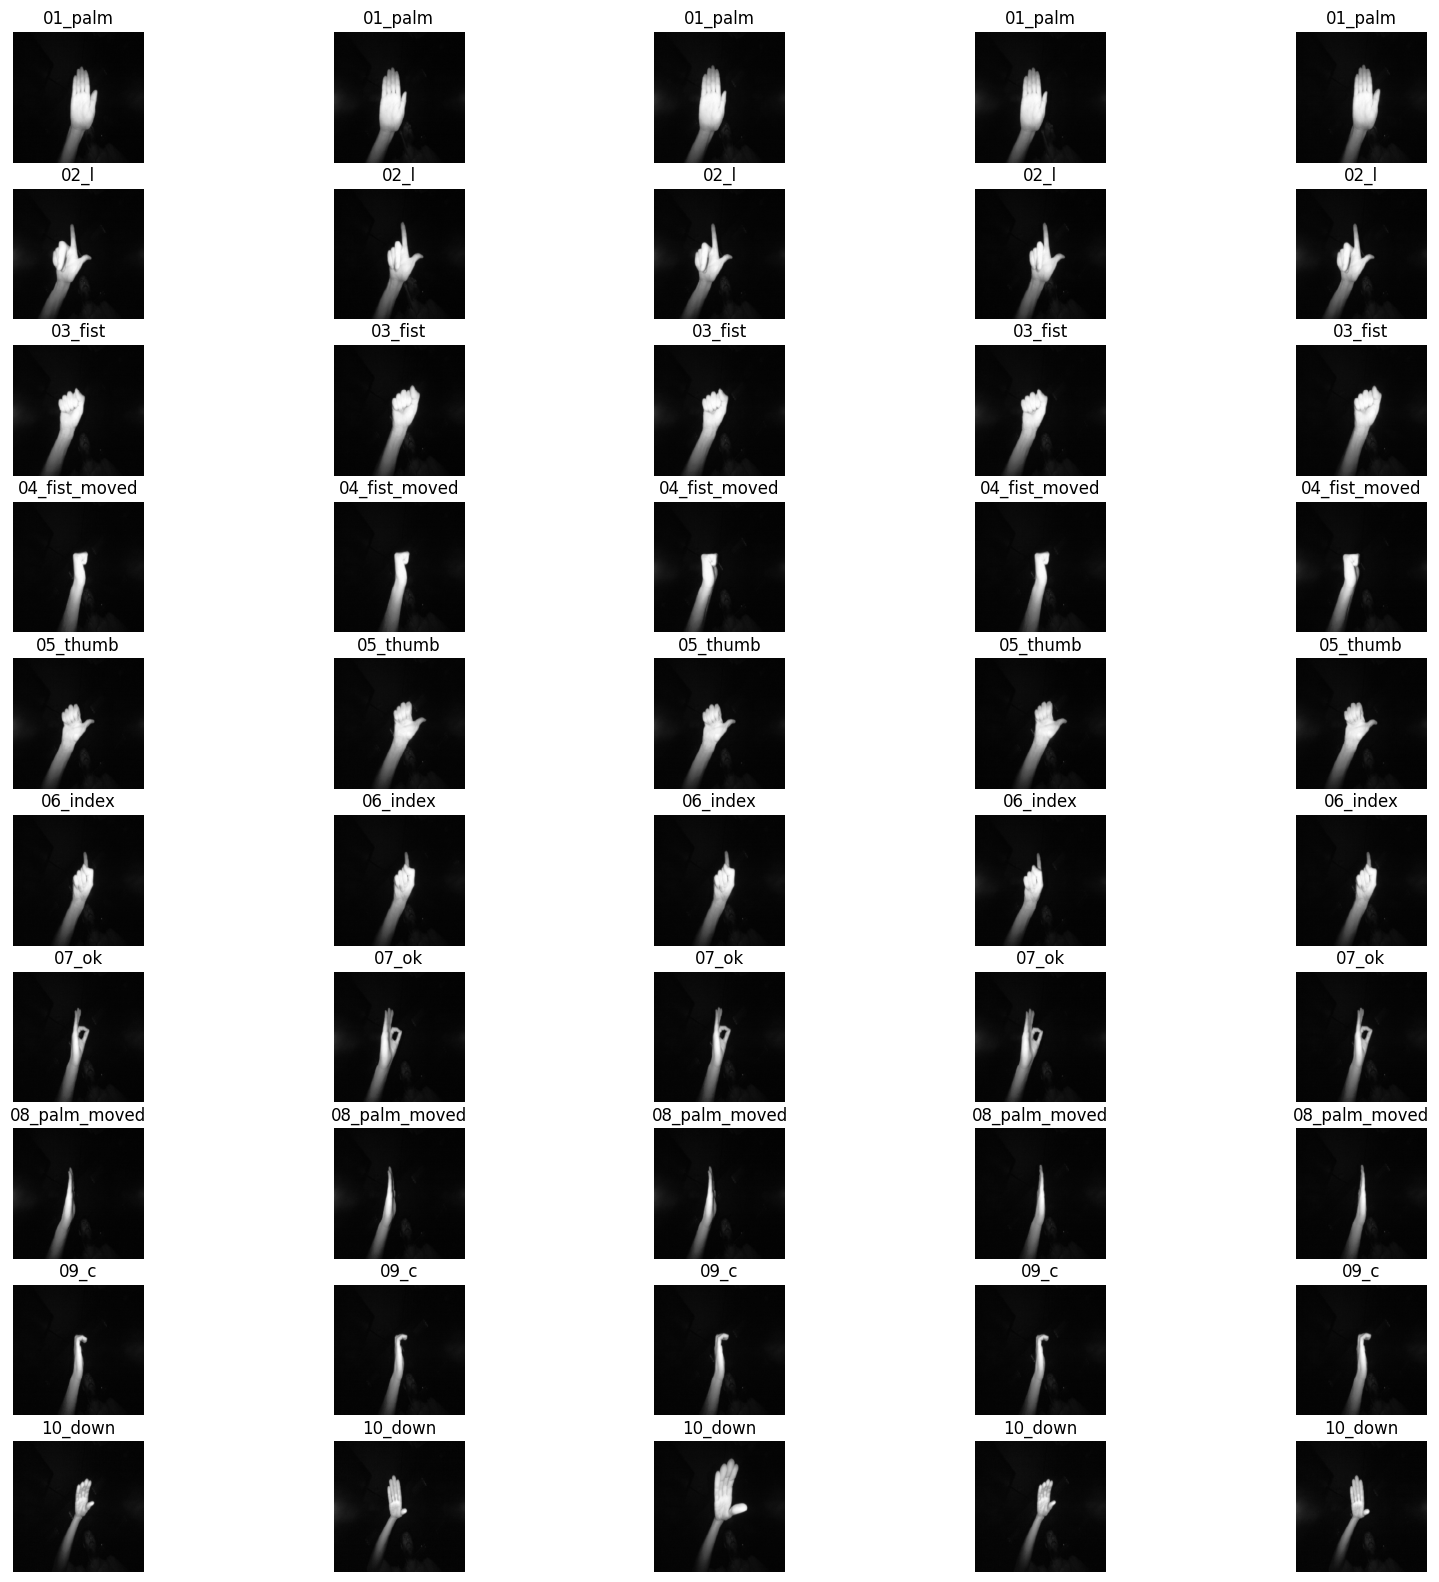

In [ ]:
gesture_folders = [
    '01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb',
    '06_index', '07_ok', '08_palm_moved', '09_c', '10_down'
]
label_map = {gesture: idx for idx, gesture in enumerate(gesture_folders)}

# Display the images
display_images(file_paths, labels, label_map)

In [ ]:

def get_file_paths_01_palm(base_path):
    file_paths = []
    subject_folders = os.listdir(base_path)
    for subject in subject_folders:
        subject_path = os.path.join(base_path, subject, '01_palm')
        if os.path.isdir(subject_path):
            count = 0
            for img_file in os.listdir(subject_path):
                if count >= 10:
                    break
                img_path = os.path.join(subject_path, img_file)
                file_paths.append(img_path)
                count += 1
    return file_paths

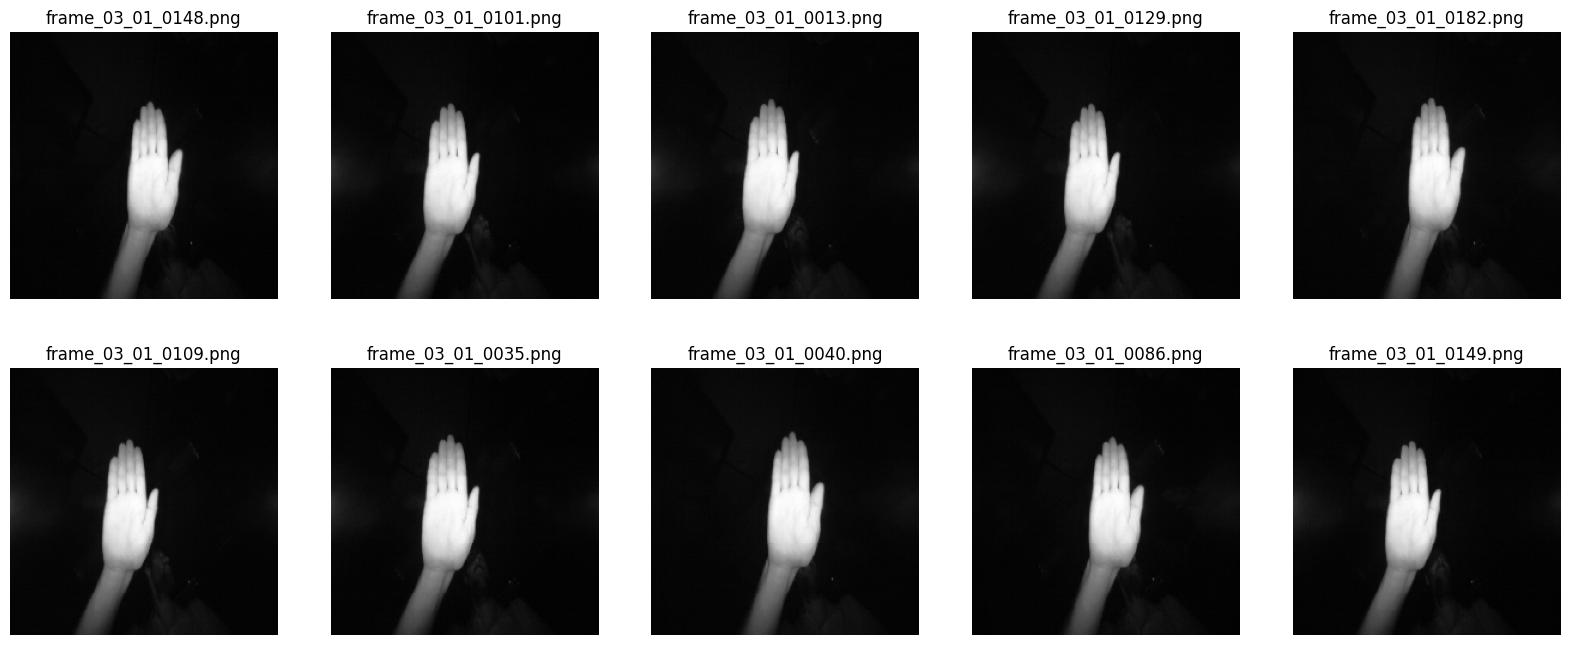

In [ ]:
def display_images(file_paths):
    plt.figure(figsize=(20, 8))
    for i, img_path in enumerate(file_paths[:10]):  # Ensure only 10 images are displayed
        img = load_img(img_path, color_mode='grayscale', target_size=(img_size, img_size))
        img = img_to_array(img) / 255.0
        plt.subplot(2, 5, i + 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(os.path.basename(img_path))
        plt.axis('off')
    plt.show()

# Get the file paths
file_paths_01_palm = get_file_paths_01_palm(dataset_path)
display_images(file_paths_01_palm)

In [ ]:
labels_str = [str(label) for label in labels]
dataframe = pd.DataFrame({'filename': file_paths, 'class': labels_str})

NameError: name 'labels' is not defined

In [ ]:
datagen = ImageDataGenerator(
    rescale=1/255.0,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    validation_split=0.2  # Reserve 20% of the data for validation
)

train_generator = datagen.flow_from_dataframe(
    dataframe=dataframe,
    x_col='filename',
    y_col='class',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=dataframe,
    x_col='filename',
    y_col='class',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

NameError: name 'ImageDataGenerator' is not defined

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

NameError: name 'Sequential' is not defined